In [2]:
import sklearn
print(sklearn.__version__)

1.6.1


In [1]:
from sklearn.datasets import load_iris
iris = load_iris()
print(iris.data[:5])

[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]


In [2]:
import torch
import numpy as np
numpy_array = np.array([1, 2, 3, 4, 5])
torch_tensor = torch.tensor(numpy_array)
print(torch_tensor)

tensor([1, 2, 3, 4, 5])


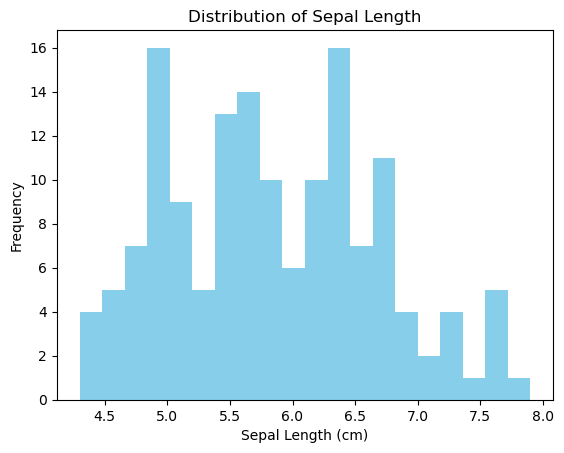

In [3]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
iris = load_iris()
plt.hist(iris.data[:, 0], bins=20, color='skyblue')
plt.title('Distribution of Sepal Length')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Frequency')
plt.show()

In [4]:
import torch
# Create a 1D tensor
tensor_1d = torch.tensor([1, 2, 3, 4])
print("1D Tensor:", tensor_1d)
# Create a 2D tensor of zeros
tensor_2d = torch.zeros((2, 3))
print("2D Tensor of Zeros:\n", tensor_2d)
# Create a random 3x3 tensor
tensor_random = torch.rand((3, 3))
print("Random 3x3 Tensor:\n", tensor_random)

1D Tensor: tensor([1, 2, 3, 4])
2D Tensor of Zeros:
 tensor([[0., 0., 0.],
        [0., 0., 0.]])
Random 3x3 Tensor:
 tensor([[0.5468, 0.5870, 0.6651],
        [0.9515, 0.7716, 0.6543],
        [0.0766, 0.4396, 0.5921]])


In [5]:
from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier()
clf.fit(iris.data, iris.target)
print(clf.score(iris.data, iris.target))

1.0


In [7]:
pip install torch torchvision matplotlib


   ---------------------------------------- 0.0/4.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/4.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/4.3 MB ? eta -:--:--
   -- ------------------------------------- 0.3/4.3 MB ? eta -:--:--
   ---- ----------------------------------- 0.5/4.3 MB 1.8 MB/s eta 0:00:03
   ------------ --------------------------- 1.3/4.3 MB 2.6 MB/s eta 0:00:02
   ------------------- -------------------- 2.1/4.3 MB 3.0 MB/s eta 0:00:01
   ------------------------ --------------- 2.6/4.3 MB 3.1 MB/s eta 0:00:01
   ---------------------------------- ----- 3.7/4.3 MB 3.1 MB/s eta 0:00:01
   ---------------------------------------- 4.3/4.3 MB 3.1 MB/s eta 0:00:00


In [2]:
import torchvision.transforms as transforms 
import torchvision.datasets as datasets 
# Basic transformations for the CIFAR-10 dataset 
transform = transforms.Compose([transforms.ToTensor(), 
transforms.Normalize((0.5,), (0.5,))]) #It rescales the pixel values to have a mean of 0.5 and a standard deviation of 0.5,
#which often helps the network train faster and better.
# Load the CIFAR-10 dataset 
dataset = datasets.CIFAR10(root='./data', train=True, 
download=True, transform=transform)

In [3]:
from torch.utils.data import random_split, DataLoader

# 关键：替换为你的QMUL ID最后一位数字
last_digit_of_id = 0
# 1. 拆分训练集-验证集（ID尾号0-4：70-30拆分；5-9：80-20拆分）
split_ratio = 0.7 if last_digit_of_id <= 4 else 0.8
train_size = int(split_ratio * len(dataset))  # 训练集样本数
val_size = len(dataset) - train_size  # 验证集样本数
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# 2. 设置批次大小（batch_size = 32 + ID最后一位）
batch_size = 32 + last_digit_of_id
#It determines how many images are processed at once before the model's parameters are updated.

# 3. 创建DataLoader（批量加载数据 laod the training data in batches，加速训练）
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True  # to introduce randomness and prevent the model from learning the order of samples.
)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False  # 验证集无需打乱
)

# 验证配置是否正确
print(f"训练集样本数：{train_size}，验证集样本数：{val_size}")
print(f"批次大小：{batch_size}")

训练集样本数：35000，验证集样本数：15000
批次大小：32


In [18]:
import torch
import torch.optim as optim

# 定义神经网络模型（输入层→展平层→隐藏层→输出层）
model = torch.nn.Sequential(
    torch.nn.Flatten(),  # 展平层：将3×32×32的图像转为1维向量vector（3×32×32=3072个元素）
    torch.nn.Linear(3072, 512),  # 全连接层1（输入3072维，输出512维）
    torch.nn.ReLU(),  # 激活函数：introduces non-linearity to the model, 
   # allowing it to learn complex patterns.
    torch.nn.Linear(512, 10)  # 全连接层2（输入512维，输出10维→对应10个类别）
)

# 损失函数与优化器
criterion = torch.nn.CrossEntropyLoss()  # 交叉熵损失：适用于多分类任务
learning_rate = 0.001 + (last_digit_of_id * 0.0001)  # 学习率=0.001 + 0.0001×ID尾号
#This hyperparameter controls how much the model's parameters are adjusted
#with respect to the loss gradient during optimization.
optimizer = optim.Adam(model.parameters(), lr=learning_rate)  # Adam优化器（常用且稳定）
#update the model weights to minimize the loss function.

# 训练轮数Epochs=100 + ID尾号（示例：ID尾号7→107轮）
num_epochs = 100 + last_digit_of_id

# 验证参数是否正确
print(f"训练轮数：{num_epochs}，学习率：{learning_rate:.4f}")

训练轮数：100，学习率：0.0010


In [19]:
# 初始化记录列表（存储每轮的损失和准确率）
train_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(num_epochs):
    # -------------------------- 训练阶段 --------------------------
    model.train()  # 设为训练模式（启用Dropout、BatchNorm等，本模型无但需规范）
    running_loss = 0.0  # 记录每轮总损失
    correct = 0  # 记录正确分类的样本数
    total = 0  # 记录总样本数

    for inputs, labels in train_loader:
        optimizer.zero_grad()  # 清空上一轮梯度（避免累积）
        #Clears old gradients from the previous batch. Pytorch accumulates gradients by default, 
        #so this is necessary for a fresh start.
        outputs = model(inputs)  # 模型预测 __Forward pass
        loss = criterion(outputs, labels)  # 计算损失
        loss.backward()  # 反向传播（计算梯度）
        #Backward pass: Calculates the gradients of the loss with respect to every weight in the network.
        optimizer.step()  # 更新参数（梯度下降）

        # 统计损失和准确率
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)  # 取预测概率最大的类别（维度1为类别）
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    # 计算当前轮训练损失和准确率
    train_accuracy = 100 * correct / total
    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    train_accuracies.append(train_accuracy)
    print(f"Epoch {epoch+1}/{num_epochs} | 训练损失：{avg_train_loss:.4f} | 训练准确率：{train_accuracy:.2f}%")

    # -------------------------- 验证阶段 --------------------------
    model.eval()  # 设为验证模式（禁用Dropout、BatchNorm等）
    correct = 0
    total = 0
a
    with torch.no_grad():  # 禁用梯度计算（节省内存，加速验证）
        for inputs, labels in val_loader:
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
#as we only need to calculate the accuracy without updating weights during validation
# 计算当前轮验证准确率
    val_accuracy = 100 * correct / total
    val_accuracies.append(val_accuracy)
    print(f"Epoch {epoch+1}/{num_epochs} | 验证准确率：{val_accuracy:.2f}%\n")

Epoch 1/100 | 训练损失：1.7402 | 训练准确率：39.87%
Epoch 1/100 | 验证准确率：41.75%

Epoch 2/100 | 训练损失：1.5513 | 训练准确率：46.78%
Epoch 2/100 | 验证准确率：45.61%

Epoch 3/100 | 训练损失：1.4556 | 训练准确率：50.15%
Epoch 3/100 | 验证准确率：46.83%

Epoch 4/100 | 训练损失：1.3932 | 训练准确率：52.51%
Epoch 4/100 | 验证准确率：47.30%

Epoch 5/100 | 训练损失：1.3242 | 训练准确率：55.13%
Epoch 5/100 | 验证准确率：48.00%

Epoch 6/100 | 训练损失：1.2572 | 训练准确率：57.54%
Epoch 6/100 | 验证准确率：47.16%

Epoch 7/100 | 训练损失：1.2017 | 训练准确率：59.55%
Epoch 7/100 | 验证准确率：47.73%

Epoch 8/100 | 训练损失：1.1458 | 训练准确率：61.68%
Epoch 8/100 | 验证准确率：48.73%

Epoch 9/100 | 训练损失：1.0947 | 训练准确率：63.39%
Epoch 9/100 | 验证准确率：49.69%

Epoch 10/100 | 训练损失：1.0486 | 训练准确率：65.16%
Epoch 10/100 | 验证准确率：48.99%

Epoch 11/100 | 训练损失：0.9946 | 训练准确率：66.95%
Epoch 11/100 | 验证准确率：49.45%

Epoch 12/100 | 训练损失：0.9533 | 训练准确率：68.58%
Epoch 12/100 | 验证准确率：49.75%

Epoch 13/100 | 训练损失：0.9197 | 训练准确率：69.70%
Epoch 13/100 | 验证准确率：49.73%

Epoch 14/100 | 训练损失：0.8772 | 训练准确率：71.48%
Epoch 14/100 | 验证准确率：49.21%

Epoch 15/100 | 训练损失：0.84

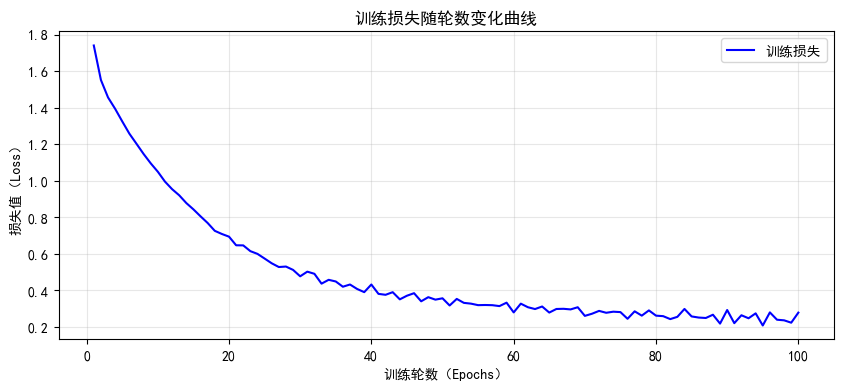

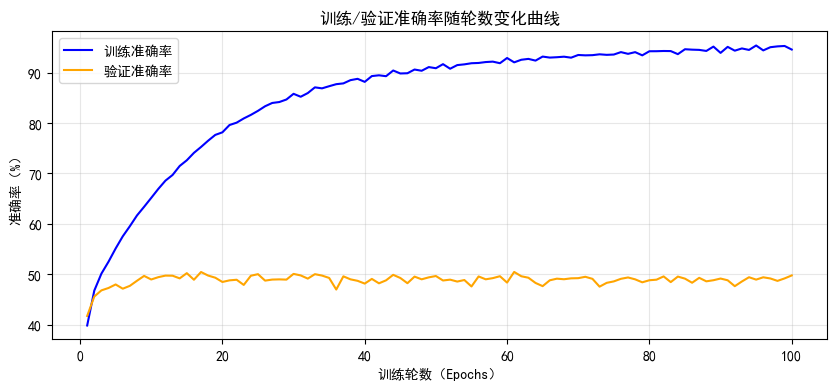

In [20]:
import matplotlib.pyplot as plt

# 设置中文字体（可选，避免中文乱码）
plt.rcParams['font.sans-serif'] = ['SimHei']  # Windows用；Mac用['Arial Unicode MS']

# 图1：训练损失 vs 训练轮数
plt.figure(figsize=(10, 4))
plt.plot(range(1, num_epochs + 1), train_losses, color='blue', label='训练损失')
plt.xlabel('训练轮数（Epochs）')
plt.ylabel('损失值（Loss）')
plt.title('训练损失随轮数变化曲线')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('training_loss.png', dpi=300, bbox_inches='tight')  # 保存图片（用于报告）
plt.show()

# 图2：训练准确率 vs 验证准确率
plt.figure(figsize=(10, 4))
plt.plot(range(1, num_epochs + 1), train_accuracies, color='blue', label='训练准确率')
plt.plot(range(1, num_epochs + 1), val_accuracies, color='orange', label='验证准确率')
plt.xlabel('训练轮数（Epochs）')
plt.ylabel('准确率（%）')
plt.title('训练/验证准确率随轮数变化曲线')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('accuracy.png', dpi=300, bbox_inches='tight')  # 保存图片（用于报告）
plt.show()